In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso,Ridge
from sklearn.preprocessing import PolynomialFeatures , StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Loading the data

In [48]:
df = pd.read_csv('data/Student_Performance.csv')
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


# Data Exploration

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [50]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [51]:
df.boxplot()

<Axes: >

In [52]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

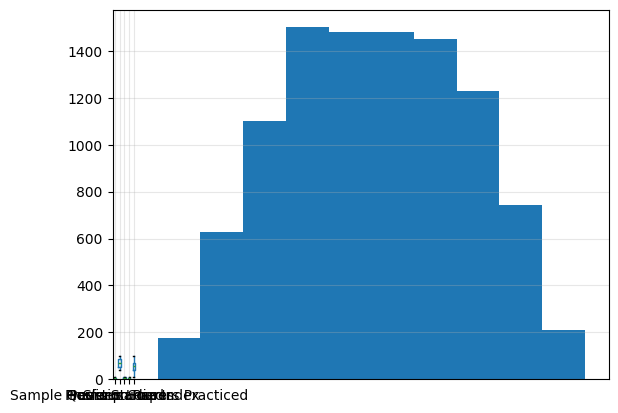

In [53]:
df['Performance Index'].hist()
plt.grid(alpha=0.3)
plt.show()

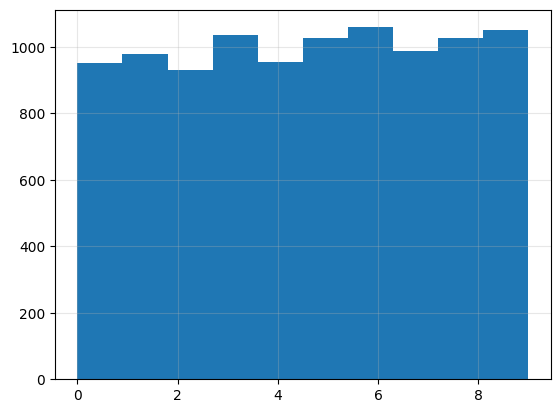

In [54]:
df['Sample Question Papers Practiced'].hist()
plt.grid(alpha=0.3)
plt.show()

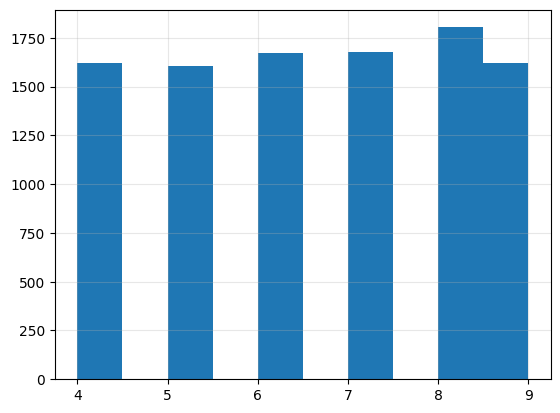

In [55]:
#Sleep Hours
df['Sleep Hours'].hist()
plt.grid(alpha=0.3)
plt.show()

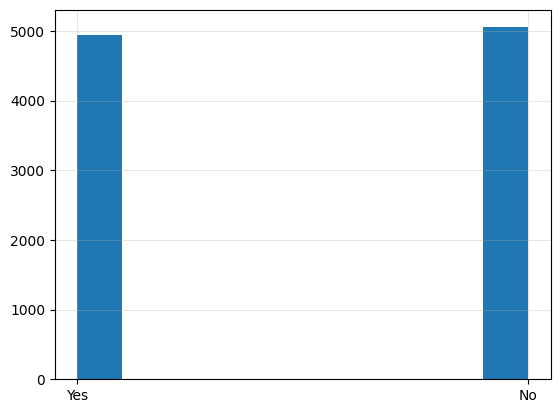

In [56]:
df['Extracurricular Activities'].hist()
plt.grid(alpha=0.3)
plt.show()

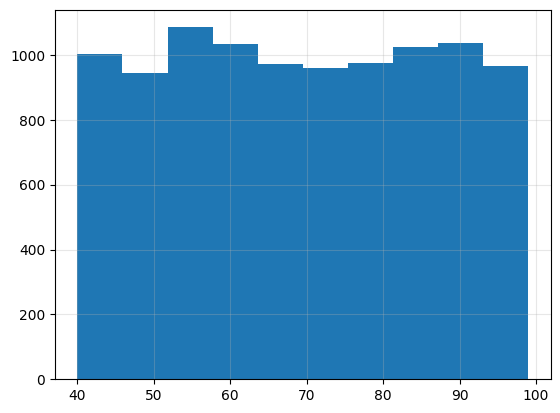

In [57]:
#Previous Scores
df['Previous Scores'].hist()
plt.grid(alpha=0.3)
plt.show()

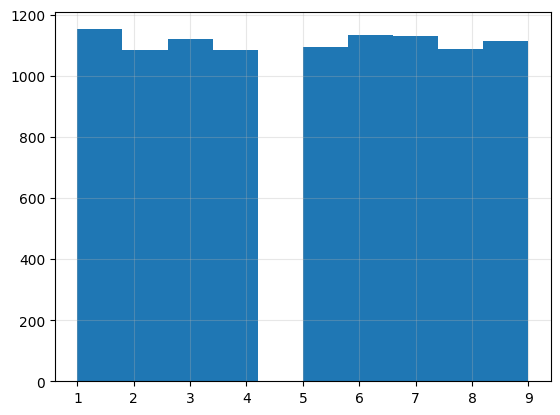

In [58]:
df['Hours Studied'].hist()
plt.grid(alpha=0.3)
plt.show()

#  Feature engineering

## null values

In [59]:
# see the null values 
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [60]:
df[df.duplicated()]

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
915,9,52,No,5,9,48.0
1477,7,61,Yes,6,8,54.0
1601,5,99,No,7,5,89.0
1786,2,62,Yes,9,4,40.0
2026,5,87,Yes,6,7,74.0
...,...,...,...,...,...,...
9644,4,91,Yes,4,3,71.0
9940,8,95,No,5,2,90.0
9954,6,97,No,8,7,92.0
9966,1,41,No,7,3,12.0


## Data Cleaning

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [62]:
df["Extracurricular Activities"].unique()

array(['Yes', 'No'], dtype=object)

In [63]:
df["Extracurricular Activities"] = df["Extracurricular Activities"].str.replace("Yes", "True")

In [64]:
df["Extracurricular Activities"] = df["Extracurricular Activities"].str.replace("No", "False")

In [67]:
df["Extracurricular Activities"] = df["Extracurricular Activities"].astype(bool)

In [65]:
df["Extracurricular Activities"].unique()

array(['True', 'False'], dtype=object)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  bool   
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: bool(1), float64(1), int64(4)
memory usage: 400.5 KB


# ML

In [70]:
# Target column
y = df['Performance Index']

# Feature columns (drop the target column)
X = df.drop('Performance Index', axis=1)

In [72]:
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression model

In [75]:
model = LinearRegression()
model.fit(X_train, y_train)
#fit
y_pred = model.predict(X_test)
#Evaluate the model (metrics explained)
mae_l = mean_absolute_error(y_test, y_pred)
mse_l = mean_squared_error(y_test, y_pred)
rmse_l = np.sqrt(mse_l)
r2_l = r2_score(y_test, y_pred)

print("--- Linear Regression Results ---")
print(f"Coefficients (slope): {model.coef_}")  # Will print all slopes
print(f"Intercept: {model.intercept_:.2f}")    # Scalar value

print(f"Mean Absolute Error (MAE): {mae_l:.2f}")
print(f"Mean Squared Error (MSE): {mse_l:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_l:.2f}")
print(f"R-squared (R2): {r2_l:.2f}")

--- Linear Regression Results ---
Coefficients (slope): [ 2.85289351e+00  1.01703572e+00 -2.22044605e-16  4.73318324e-01
  1.91726292e-01]
Intercept: -33.60
Mean Absolute Error (MAE): 1.63
Mean Squared Error (MSE): 4.18
Root Mean Squared Error (RMSE): 2.05
R-squared (R2): 0.99


## Polynomial Regression

In [76]:
poly_features = PolynomialFeatures(degree=2)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)
y_pred_poly = model_poly.predict(X_test_poly)

mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("\n--- Polynomial Regression Results (Degree 2) ---")
print(f"Mean Absolute Error (MAE): {mae_poly:.2f}")
print(f"Mean Squared Error (MSE): {mse_poly:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_poly:.2f}")
print(f"R-squared (R2): {r2_poly:.2f}")


--- Polynomial Regression Results (Degree 2) ---
Mean Absolute Error (MAE): 1.63
Mean Squared Error (MSE): 4.18
Root Mean Squared Error (RMSE): 2.04
R-squared (R2): 0.99


## Lasso Regression

In [78]:
model_lasso = Lasso(alpha=1.0)
model_lasso.fit(X_train, y_train)
y_pred_lasso = model_lasso.predict(X_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\n--- Lasso Regression Results---")
print(f"Mean Absolute Error (MAE): {mae_lasso:.2f}")
print(f"Mean Squared Error (MSE): {mse_lasso:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lasso:.2f}")
print(f"R-squared (R2): {r2_lasso:.2f}")



--- Lasso Regression Results---
Mean Absolute Error (MAE): 1.75
Mean Squared Error (MSE): 4.88
Root Mean Squared Error (RMSE): 2.21
R-squared (R2): 0.99


## Ridge Regression

In [79]:
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train, y_train)
y_pred_ridge = model_ridge.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\n--- Ridge Regression Results ---")
print(f"Mean Absolute Error (MAE): {mae_ridge:.2f}")
print(f"Mean Squared Error (MSE): {mse_ridge:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_ridge:.2f}")
print(f"R-squared (R2): {r2_ridge:.2f}")



--- Ridge Regression Results ---
Mean Absolute Error (MAE): 1.63
Mean Squared Error (MSE): 4.18
Root Mean Squared Error (RMSE): 2.05
R-squared (R2): 0.99


## Decision Tree Regressor

In [80]:
model_tree = DecisionTreeRegressor(random_state=42)
model_tree.fit(X_train, y_train)
y_pred_tree = model_tree.predict(X_test)

mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("\n--- Decision Tree Regressor Results ---")
print(f"Mean Absolute Error (MAE): {mae_tree:.2f}")
print(f"Mean Squared Error (MSE): {mse_tree:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tree:.2f}")
print(f"R-squared (R2): {r2_tree:.2f}")



--- Decision Tree Regressor Results ---
Mean Absolute Error (MAE): 2.32
Mean Squared Error (MSE): 8.70
Root Mean Squared Error (RMSE): 2.95
R-squared (R2): 0.98


## Random Forest Regressor

In [81]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n--- Random Forest Regressor Results ---")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")



--- Random Forest Regressor Results ---
Mean Absolute Error (MAE): 1.85
Mean Squared Error (MSE): 5.38
Root Mean Squared Error (RMSE): 2.32
R-squared (R2): 0.99


## SVM Regressor

In [82]:
# Scale the data for SVR
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

model_svr = SVR(kernel='rbf')
model_svr.fit(X_train_scaled, y_train_scaled)
y_pred_svr_scaled = model_svr.predict(X_test_scaled)
y_pred_svr = scaler_y.inverse_transform(y_pred_svr_scaled.reshape(-1, 1))

mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("\n--- Support Vector Regression (SVR) Results ---")
print(f"Mean Absolute Error (MAE): {mae_svr:.2f}")
print(f"Mean Squared Error (MSE): {mse_svr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_svr:.2f}")
print(f"R-squared (R2): {r2_svr:.2f}")



--- Support Vector Regression (SVR) Results ---
Mean Absolute Error (MAE): 1.66
Mean Squared Error (MSE): 4.38
Root Mean Squared Error (RMSE): 2.09
R-squared (R2): 0.99


# comparison between regression models

In [83]:
print(f"Linear Regression model R-squared (R2): {r2_l:.2f}")
print(f"Polynomial Regression R-squared (R2): {r2_poly:.2f}")
print(f"Lasso Regression R-squared (R2): {r2_lasso:.2f}")
print(f" Ridge Regression R-squared (R2): {r2_ridge:.2f}")
print(f"Decision Tree Regressor R-squared (R2): {r2_tree:.2f}")
print(f" Random Forest Regressor R-squared (R2): {r2_rf:.2f}")
print(f" SVM Regressor R-squared (R2): {r2_svr:.2f}")

Linear Regression model R-squared (R2): 0.99
Polynomial Regression R-squared (R2): 0.99
Lasso Regression R-squared (R2): 0.99
 Ridge Regression R-squared (R2): 0.99
Decision Tree Regressor R-squared (R2): 0.98
 Random Forest Regressor R-squared (R2): 0.99
 SVM Regressor R-squared (R2): 0.99
